## includes

In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

CSV_DIR = Path("../assets/data")
FIG_DIR = Path("../assets/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

CAMPAGNES = {
    "idle": ("auton_idle_025.csv", "Veille", "#55A868"),
    "jack": ("auton_jack_022.csv", "Lecture jack", "#DD5252"),
    "bt":   ("auton_bt_024.csv",   "Lecture Bluetooth", "#2793F8"),
}

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "axes.axisbelow": True,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

## read csv

In [34]:
def charger(nom):
    """Lit un CSV de campagne. current_mA est negatif en decharge, on renvoie i_mA positif."""
    df = pd.read_csv(CSV_DIR / nom, comment="#")
    df["t_h"] = df["t_s"] / 3600.0
    df["i_mA"] = -df["current_mA"].astype(float)
    df["v_mV"] = df["voltage_mV"].astype(float)
    return df

def courant_moyen(df):
    """Moyenne ponderee par le temps, insensible a la periode d'echantillonnage."""
    t = df["t_s"].to_numpy(float)
    return np.trapz(df["i_mA"].to_numpy(float), t) / (t[-1] - t[0])

def lissage(df):
    n = max(3, len(df) // 25)
    return df["i_mA"].rolling(n, center=True, min_periods=1).mean(), n

def duree_hhmm(df):
    """Duree totale de la campagne au format h:mm."""
    s = int(round(df["t_s"].iloc[-1] - df["t_s"].iloc[0]))
    return f"{s // 3600} h {(s % 3600) // 60:02d}"

donnees = {cle: charger(nom) for cle, (nom, _, _) in CAMPAGNES.items()}

## individual plot

In [35]:
def figure_campagne(cle):
    df = donnees[cle]
    _, libelle, couleur = CAMPAGNES[cle]
    fig, axes = plt.subplots(3, 1, figsize=(6.3, 6.0), sharex=True)

    axes[0].plot(df["t_h"], df["soc_pct"], color=couleur, lw=1.4)
    axes[0].set_ylabel("SoC [%]")
    axes[0].set_ylim(0, 105)
    axes[0].yaxis.set_major_locator(MultipleLocator(25))
    axes[0].set_title(libelle)

    liss, n = lissage(df)
    i_moy = courant_moyen(df)
    axes[1].plot(df["t_h"], df["i_mA"], color=couleur, lw=0.9, alpha=0.55)
    axes[1].plot(df["t_h"], liss, color=couleur, lw=1.8, label=f"moyenne glissante ({n} pts)")
    axes[1].axhline(i_moy, color="k", ls="--", lw=1.0, label=f"moyenne = {i_moy:.0f} mA")
    axes[1].set_ylabel("Courant [mA]")
    axes[1].legend(loc="upper right", framealpha=0.9)

    axes[2].plot(df["t_h"], df["v_mV"], color=couleur, lw=1.4)
    axes[2].axhline(3200, color="crimson", ls=":", lw=1.2, label="seuil superviseur (3,2 V)")
    axes[2].set_ylabel("Tension [mV]")
    axes[2].set_xlabel("Temps [h]")
    axes[2].set_xlim(0, df["t_h"].iloc[-1])
    axes[2].legend(loc="upper right", framealpha=0.9)

    fig.align_ylabels(axes)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"auton_{cle}.png")
    plt.show()

## comparison plot

In [36]:
def figure_comparaison():
    fig, axes = plt.subplots(2, 1, figsize=(6.3, 4.6), sharex=True)

    for cle, (_, libelle, couleur) in CAMPAGNES.items():
        df = donnees[cle]
        liss, _ = lissage(df)
        axes[0].plot(df["t_h"], df["soc_pct"], color=couleur, lw=1.5,
                     label=f"{libelle} ({duree_hhmm(df)})")
        axes[1].plot(df["t_h"], liss, color=couleur, lw=1.5,
                     label=f"{libelle} ({courant_moyen(df):.0f} mA)")

    axes[0].set_ylabel("SoC [%]")
    axes[0].set_ylim(0, 105)
    axes[0].yaxis.set_major_locator(MultipleLocator(25))
    axes[0].legend(loc="upper right", framealpha=0.9)

    axes[1].set_ylabel("Courant [mA]")
    axes[1].set_xlabel("Temps [h]")
    axes[1].set_xlim(0, max(d["t_h"].iloc[-1] for d in donnees.values()))
    axes[1].legend(loc="upper right", framealpha=0.9)

    fig.align_ylabels(axes)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "auton_comparaison.png")
    plt.show()

## generation

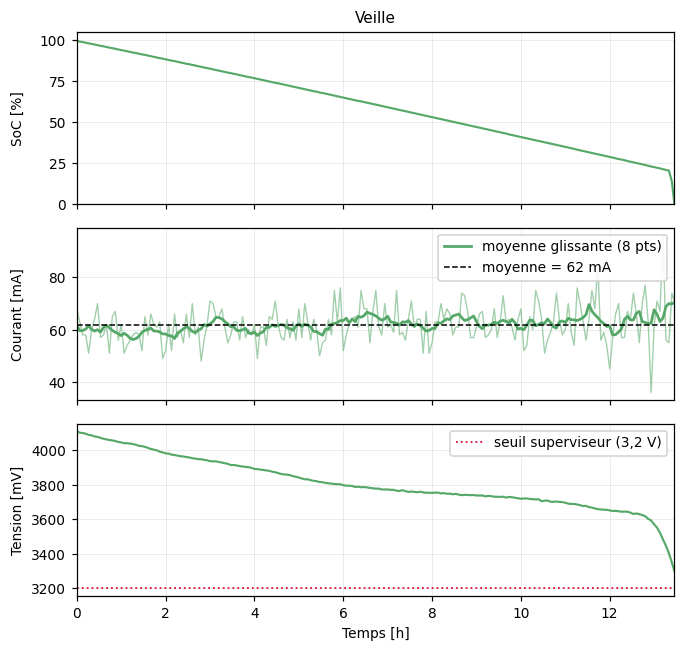

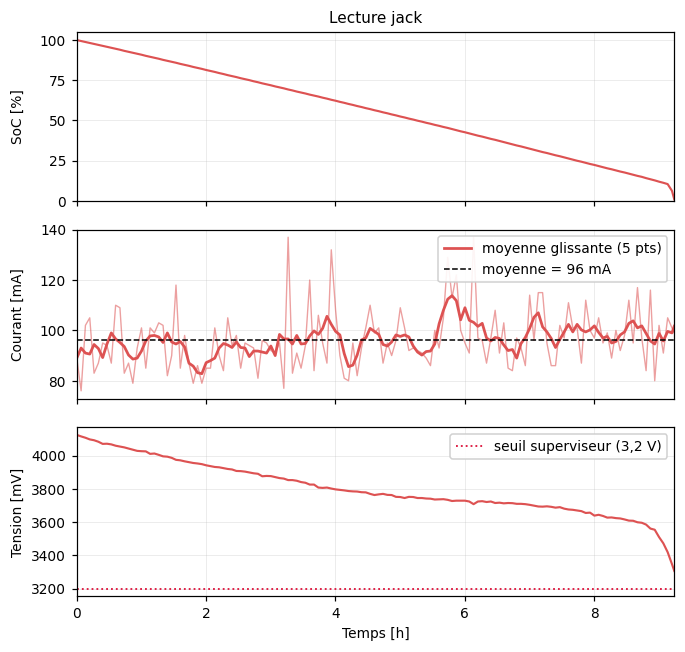

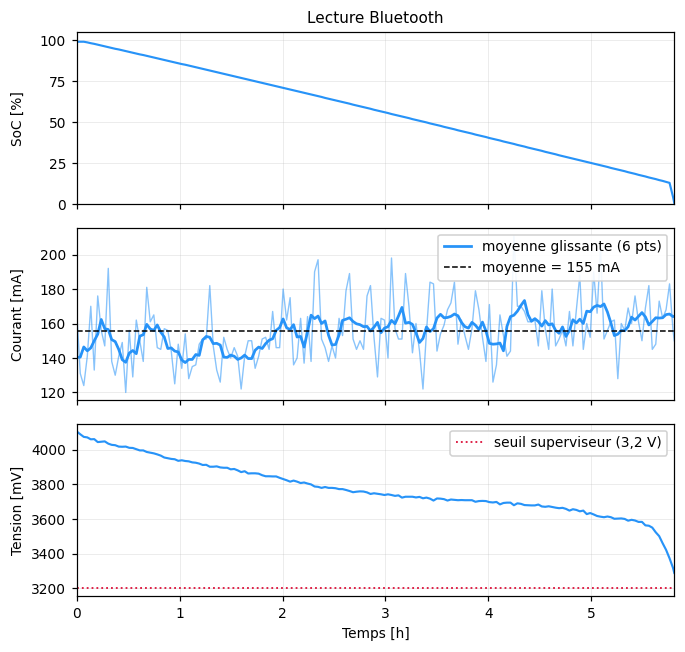

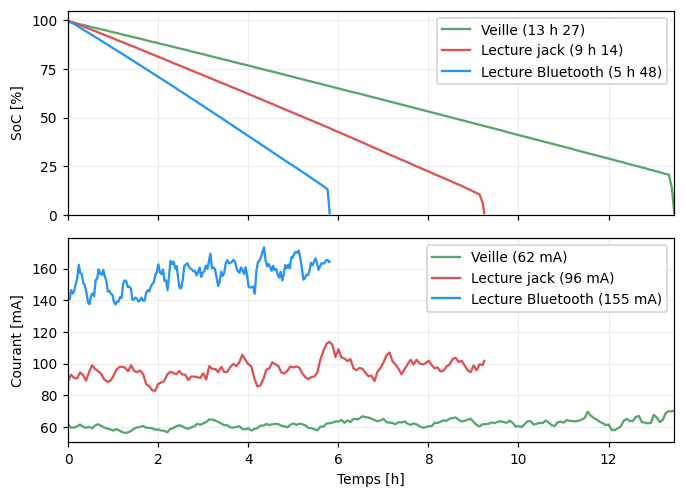

In [37]:
for cle in CAMPAGNES:
    figure_campagne(cle)
figure_comparaison()